# DLMI Lecture 03

In this assignment you will implement methods for standardizing the orientation of a medical image.

In [1]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
import time 
import sys
import os 

In [2]:
engr_dir = "/opt/nfsopt/DLMI"
idas_dir = os.path.join(os.path.expanduser('~'), "classdata")

if os.path.isdir(engr_dir):
    data_dir = engr_dir
elif os.path.isdir(idas_dir):  
    data_dir = idas_dir
else:
    print("Data directory not found")

### How to display image in Python

If the direction cosine matrix is identity, the $ijk$ image coordinate system basis has the same orientation as the $lps$ anatomical coordinate system basis. Therefore:

- $i$ : right -> $l$eft axis
- $j$ : anterior -> $p$osterior axis
- $k$ : inferior -> $s$uperior axis

Therefore the anatomical planes are accessed in the following way given SimpleITK image object `im`:

- `im[i, :, :]` -> sagittal slice $i$
- `im[:, j, :]` -> coronal slice $j$
- `im[:, :, k]` -> axial slice $k$

This is **ONLY** true if the direction cosine matrix is identity.

When a SimpleITK image is converted to a NumPy matrix, the first and last dimensions get permuted. Therefore voxel `[i, j, k]` in a SimpleITK image corresponds to NumPy matrix index `[k, j, i]`. Similarly, accessing the anatomical planes are permuted. Given a NumPy matrix `imnp`:

- `im_np[:, :, i]` -> sagittal slice $i$
- `im_np[:, j, :]` -> coronal slice $j$
- `im_np[k, :, :]` -> axial slice $k$

Again, this is only true if the direction cosine matrix is identity. 

Aside: When displaying a NumPy matrix with matplotlib, the `imshow` origin (where the [0,0] index of the array is placed when displaying an image) is by default the top left corner. The matrix will be displayed with the row index (first dimension) increasing downwards and the column index (second dimension) increasing to the right. Although this is not the same convention used for images, everything works out nicely since the first and last dimension of the image were permuted when converting to NumPy. As a result, all the anatomical planes get displayed in the correct orientation. The only exception is the superior/inferior axis. Given an identity direction cosine matrix, the `k` index will increase in the superior direction. Since the `imshow` origin is the top left corner, this will result in the anatomy being displayed upside down in the coronal and sagittal views. In other words, the superior direction is down when it should be up. A simple fix is to set `origin = lower` when displaying coronal and sagittal slices.

### Standardize image orientation

In this assignment you will work with an image that has a non-identity direction cosine matrix, and you will standardize the image such that it has an identity cosine matrix. This will ensure all images are oriented the same and that we can use the above conventions to consistently access / display the anatomical planes.

First load the following images in Slicer:
- `CTChest_scan1.nii.gz`
- `CTChest_scan2.nii.gz`
- `CTChest_scan3.nii.gz`.

All images are sampled from the same underlying function. However, the image coordinate systems defintion with respect to the anatomical coordinate system is different. 

Do the images appear the same in Slicer? (answer below).

## ANSWER: Yes, the images appears the same despite slightly different meta data include direction, spacing, and origin

Now read the images using SimpleITK.

In [3]:
fn1 = os.path.join(data_dir, "lecture03", "CTChest_scan1.nii.gz")
fn2 = os.path.join(data_dir, "lecture03", "CTChest_scan2.nii.gz")
fn3 = os.path.join(data_dir, "lecture03", "CTChest_scan3.nii.gz")

im1 = sitk.ReadImage(fn1)
im2 = sitk.ReadImage(fn2)
im3 = sitk.ReadImage(fn3)

im1np = sitk.GetArrayFromImage(im1)
im2np = sitk.GetArrayFromImage(im2)
im3np = sitk.GetArrayFromImage(im3)

### Part 1

Complete the function below for displaying a figure with 3 subplots. The subplots should display the axial, coronal, and sagittal views of a 3D image. Your code can assume that the input image will have an identity direction matrix. For credit, your code will need to properly display input images that have non-isotropic voxels. Additionally, the orientation needs to be correctly displayed (should match the orientation in Slicer). Hint: you may need to change the imshow origin for some views, see aside above. Complete the function below by replacing the XXXs with appropriate code.

In [4]:
def myshow_multiview(im, slice_inds, min_intensity, max_intensity):
    """
    Displays three inline images corresponding to the anatomical planes froma 3D image.

    The input image must be 3D.

    Assumes an identity direction cosine matrix!

    Inputs:
    - im (sitk.Image): SimpleITK image to display
    - slice_inds (int, int, int): Tuple with indices of slices to display: (sagittal_ind, coronal_ind, axial_ind)
    - min_intensity (int): Minimum display intensity (mapped to black)
    - max_intensity (int): Maximum display intensity (mapped to white)

    Returns:
    """
    
    # Create figure with 3 subplots    
    fig, ax = plt.subplots(1,3, figsize = (12,4))

    # Convert SimpleITK image to Numpy Array
    array = sitk.GetArrayFromImage(im)

    # Get image spacing in SimpleITK order: 
    i, j, k = im.GetSpacing()

    # # Slice indices
    sagittal_ind, coronal_ind, axial_ind = slice_inds

    
    # Extract slices
    sagittal = array[:, :, sagittal_ind]      
    coronal  = array[:, coronal_ind, :]       
    axial    = array[axial_ind, :, :]          

    # ---------------------------------------------------------
    
    # Display each slice
    ax[0].imshow(
        sagittal,
        cmap="gray",
        vmin=min_intensity,
        vmax=max_intensity,
        aspect= k / j,
        origin="lower"
    )

    ax[1].imshow(
        coronal,
        cmap="gray",
        vmin=min_intensity,
        vmax=max_intensity,
        aspect= k / i,
        origin="lower"
    )

    ax[2].imshow(
        axial,
        cmap="gray",
        vmin=min_intensity,
        vmax=max_intensity,
        aspect= j / i,
        origin="lower"
    )

    # Add title to each view
    planes = ["Sagittal", "Coronal", "Axial"]
    for x,p in enumerate(planes):
        ax[x].set_title(p)

Below, call the `myshow_multiview` function to display `im1`. `im1` is provided as a reference image to check your `myshow_multiview` implementation, as it follows the assumption of having an identify direction cosine matrix. For full credit, the displayed image must match what you obsereve when opening `im1` in Slicer (i.e., aspect ratio and orientation for each view).

(512, 512, 139)


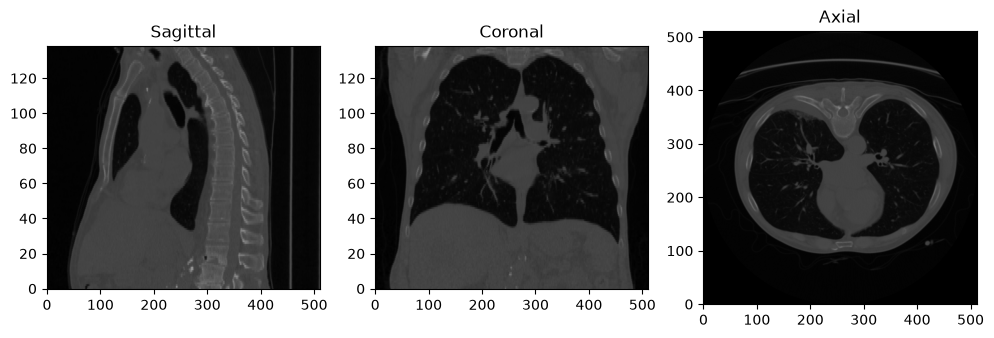

In [5]:
######################################
#######         TODO           #######
######################################

print(im1.GetSize())

myshow_multiview(im1, (256, 256, 69), -1054, 3071)



Naively, try calling the `myshow_multiview` function to display `im2` and `im3`.

(139, 512, 512)
(512, 512, 139)


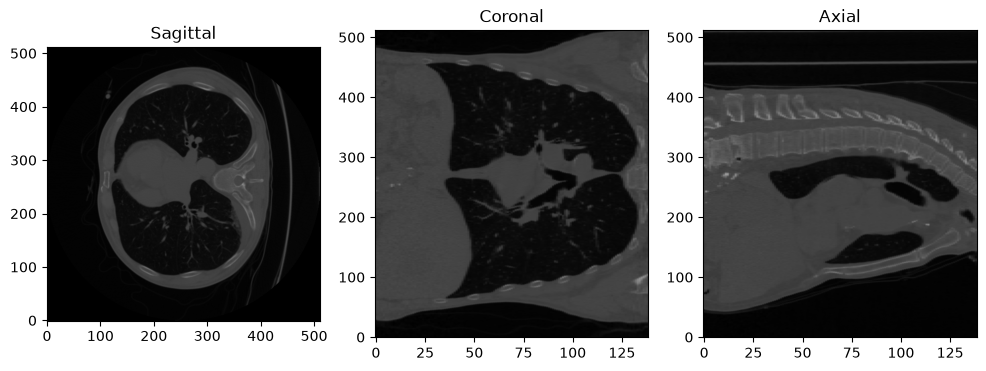

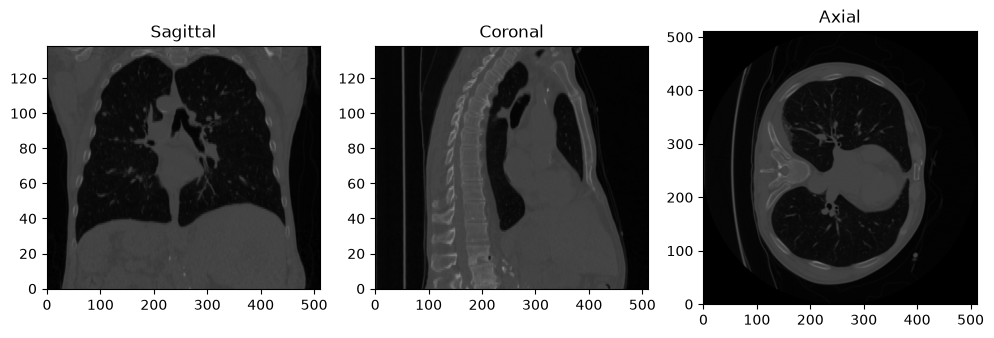

In [6]:
######################################
#######         TODO           #######
######################################

print(im2.GetSize())
print(im3.GetSize())

myshow_multiview(im2, (69, 256, 256), -1054, 3071)

myshow_multiview(im3, (256, 256, 69), -1054, 3071)

Compare the three views of `im1` and `im2` and `im3`. How are they the same or different?

## Answer: The images IM2 and IM3 are incorrectly rotated and the image labs are incorrect for the output images, when compared to IM1

Next, compare the meta data (size, spacing, origin, direction cosine matrix) betewen `im1` and `im2` and `im3`.
Describe the similarities/differences (in the markdown cell below).

In [73]:
######################################
#######         TODO           #######
######################################

print(
    f"Size: {im1.GetSize(),im2.GetSize(), im3.GetSize() }\n"
    f"Spacing: {im1.GetSpacing(), im2.GetSpacing(), im3.GetSpacing()}\n"
    f"Origin: {im1.GetOrigin(), im2.GetOrigin(), im3.GetOrigin()}\n"
)

print( f"Direction Cosine: {np.array(im1.GetDirection() ).reshape(3,3)}")
print( f"Direction Cosine: {np.array(im2.GetDirection() ).reshape(3,3)}")
print( f"Direction Cosine: {np.array(im3.GetDirection() ).reshape(3,3)}")

Size: ((512, 512, 139), (139, 512, 512), (512, 512, 139))
Spacing: ((0.7617189884185791, 0.7617189884185791, 2.5), (2.5, 0.7617189884185791, 0.7617189884185791), (0.7617189884185791, 0.7617189884185791, 2.5))
Origin: ((-195.0, -171.6999969482422, -347.75), (195.0, 150.0, 350.0), (50.0, 25.0, 150.0))

Direction Cosine: [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Direction Cosine: [[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
Direction Cosine: [[ 0. -1.  0.]
 [-1.  0.  0.]
 [ 0.  0.  1.]]


## ANSWER: the metadata is similar for all three images, but the values are shifted amongst all three images. 

Note: the `GetDirection()` class method, returns a tuple of 9 elements: a vector representing a matrix in row major order. To get the corresponding $3\times3$ matrix you can convert it to a numpy array, and use the `np.reshape()` function, i.e., `np.array( im.GetDirection() ).reshape(3,3)` given SimpleITK image `im`.

In the remainder of the assignment you wil implement the two approaches for standardizing an image such that the direction cosine matrix is transformed to the identity matrix. 


### Part 2

Implement the more general approach for orientation standardization using `sitk.ResampleImageFilter` as described in Lecture 03. In this approach you should also standardize the spacing to (1,1,1). Apply the method to `im2` and `im3`. The function should only have a single input - the image to be standardized (`im1` should not be used in the remainder of the assignment).

In [24]:
def standardize_resample(im):
    """
    Standardizes the orientation (identity) and spacing (1mm isotropic)
    of an input image using SimpleITK ResampleImageFilter.

    Inputs:
    - im (sitk.Image): SimpleITK image to standardize

    Returns:
    - im_stand (sitk.Image): standardized SimpleITK image
    """
    ######################################
    #######         TODO           #######
    ######################################
    
   
    #######   Input information    #######

    # Desired output spacing
    output_spacing = (1.0, 1.0, 1.0)

    # Identity direction matrix
    output_direction = (1.0, 0.0, 0.0,
                        0.0, 1.0, 0.0,
                        0.0, 0.0, 1.0)

    # Input size
    size = im.GetSize()

    #######  Find physical bounds   ######
   
    # Get physical coordinates of all 8 corners
    corners = []

    for k in [0, size[0] - 1]:
        for j in [0, size[1] - 1]:
            for i in [0, size[2] - 1]:
                point = im.TransformIndexToPhysicalPoint((k, j, i))
                corners.append(point)

    corners = np.array(corners)

    #new identity coordinate system
    min_point = corners.min(axis=0)
    max_point = corners.max(axis=0)

    
    #######   Determine output size ######
    
    output_size = np.ceil(
        (max_point - min_point) / np.array(output_spacing)
    ).astype(int) + 1

    output_size = tuple(output_size.tolist())

    ######################################
    #######      Resample image     ######
    
    resampler = sitk.ResampleImageFilter()

    # Output grid
    resampler.SetOutputSpacing(output_spacing)
    resampler.SetSize(output_size)
    resampler.SetOutputDirection(output_direction)
    resampler.SetOutputOrigin(tuple(min_point))

    # Identity transform:
    resampler.SetTransform(sitk.Transform(3, sitk.sitkIdentity))

    # Interpolation
    resampler.SetInterpolator(sitk.sitkLinear)

    # resampling
    im_stand = resampler.Execute(im)

    return im_stand

# call function with im2 as input
im2_stand_a = standardize_resample(im2)

Display the 3 views of the standardized `im2` to confirm the expected orientation. Also, print the metadata for the standardized image. Repeat with `im3`


Standardized im2
Spacing: (1.0, 1.0, 1.0)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

Standardized im3
Spacing: (1.0, 1.0, 1.0)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


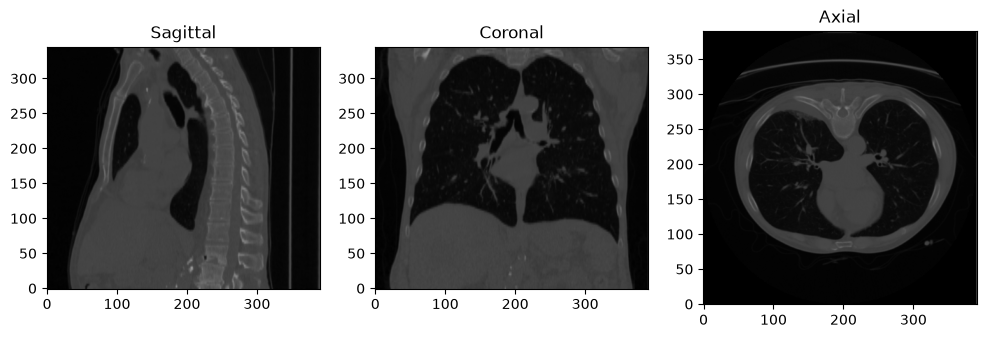

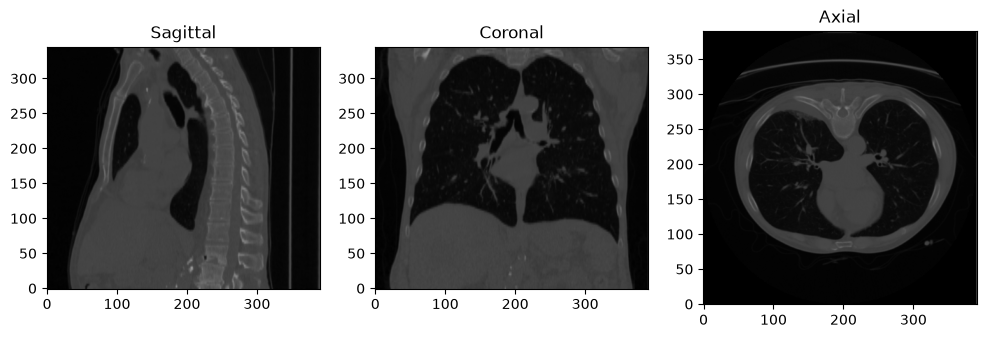

In [25]:
######################################
#######         TODO           #######
######################################
#IMage im3 function call
im3_stand_a = standardize_resample(im3)

#size for slicer
size = im2_stand_a.GetSize()  #im2
size3 = im3_stand_a.GetSize()  #im3

# Display Slicer
stand_inds_2 = (
    size[0] // 2,   # sagittal
    size[1] // 2,   # coronal
    size[2] // 2    # axial
)

stand_inds_3 = (
    size3[0] // 2,   # sagittal
    size3[1] // 2,   # coronal
    size3[2] // 2    # axial
)

#Display standardized images
myshow_multiview(im2_stand_a, stand_inds_2, -1054, 3071)
myshow_multiview(im3_stand_a, stand_inds_3, -1054, 3071)

##print metadata to confirm changes
print("\nStandardized im2")
print("Spacing:", im2_stand_a.GetSpacing())
print("Direction:", im2_stand_a.GetDirection())

print("\nStandardized im3")
print("Spacing:", im3_stand_a.GetSpacing())
print("Direction:", im3_stand_a.GetDirection())


### Part 3

Implement the standardization approach which assumes the direction cosine matrix consists of 0 and $\pm1$. The identity matrix can be achieved by combinations of permutations and/or flips of the (i j k) coordinate system. SimpleITK has a `sitk.PermuteAxes()` and `sitk.Flip()` filter. This can also be accomplished using NumPy functions `np.transpose()` and `np.flip()`, but be sure to consider the NumPy indices are `[k, j, i]`.  

In [44]:
######################################
#######         TODO           #######
######################################
def standardize_permute_flip(im):
    """
    Standardizes the orientation (identity)
    of an input image using the permute and flip approach.

    Inputs:
    - im (sitk.Image): SimpleITK image to standardize

    Returns:
    - im_stand (sitk.Image): standardized SimpleITK image
    """

    ######################################
    #######   Get direction matrix  ######
    ######################################

    D = np.array(im.GetDirection()).reshape(3, 3)

    ######################################
    #######   Determine permutation  #####
    ######################################

    # Find the input axis associated with each row
    permutation = [
        int(np.argmax(np.abs(D[i, :])))
        for i in range(3)
    ]

    ######################################
    #######      Determine flips    ######
    ######################################

    flip = [
        bool(D[i, permutation[i]] < 0)
        for i in range(3)
    ]

    ######################################
    #######      Permute axes       ######
    ######################################

    permute_filter = sitk.PermuteAxesImageFilter()

    permute_filter.SetOrder(permutation)

    im_stand = permute_filter.Execute(im)

    ######################################
    #######         Flip axes       ######
    ######################################

    flip_filter = sitk.FlipImageFilter()

    flip_filter.SetFlipAxes(flip)

    flip_filter.SetFlipAboutOrigin(False)

    im_stand = flip_filter.Execute(im_stand)

    ######################################
    #######    Set identity direction #####
    ######################################

    im_stand.SetDirection(
        (1.0, 0.0, 0.0,
         0.0, 1.0, 0.0,
         0.0, 0.0, 1.0)
    )

    return im_stand

Display the 3 views of the standardized image to confirm the expected orientation. Also, print the metadata for the standardized image.


Original Size:
(139, 512, 512)

Standardized Size:
(512, 512, 139)
Original direction:
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]

Standardized direction:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Original spacing: (2.5, 0.7617189884185791, 0.7617189884185791)
Standardized spacing: (0.7617189884185791, 0.7617189884185791, 2.5)


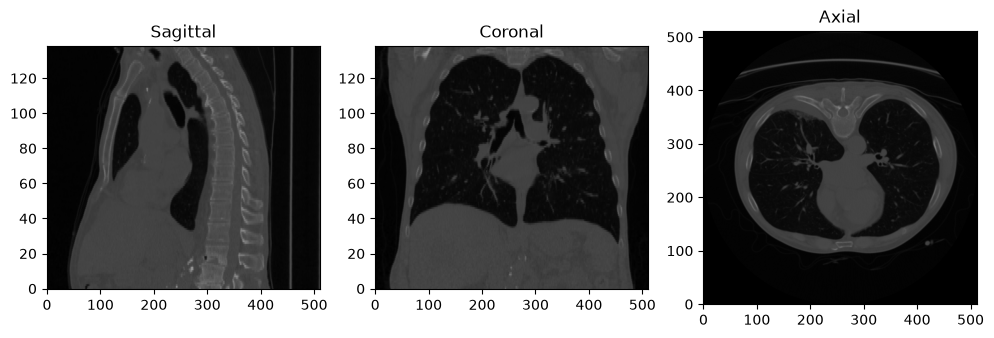

In [45]:
######################################
#######         TODO           #######
######################################

# call function with im2 as input
im2_stand_b = standardize_permute_flip(im2)

sizeb = im2_stand_b.GetSize()  #im2 size

# Display Slicer
stand_inds_b = (
    sizeb[0] // 2,   # sagittal
    sizeb[1] // 2,   # coronal
    sizeb[2] // 2    # axial
)

print("\nOriginal Size:")
print(im2.GetSize())

print("\nStandardized Size:")
print(sizeb)

print("Original direction:")
print(np.array(im2.GetDirection()).reshape(3, 3))

print("\nStandardized direction:")
print(np.array(im2_stand_b.GetDirection()).reshape(3, 3))

print("\nOriginal spacing:", im2.GetSpacing())
print("Standardized spacing:", im2_stand_b.GetSpacing())

#dispaly image for im2
myshow_multiview(im2_stand_b, stand_inds_b, -1054, 3071)


How do the two methods compare? Do they produce the same or different standardized image? How does the metadata compare to the original image?

## Answer: Both methods produce the same corrected image. Compared to the original, the method provides an approach to properly Standardization the image for downstream task